# Chapter 05 Cross-Validation: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-05-cross-validation-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Chapter 4 left one question unanswered. The latency model there added a regularization penalty
controlled by a strength $\lambda$, and Lasso zeroed out a noise predictor once $\lambda$ grew
large enough. But how large is large enough?

Picking $\lambda$ by looking at how well the model fits the data it was trained on cannot answer
that question. A large enough model always fits its own training data better as it grows more
flexible, whether or not it has learned anything that generalizes. *Cross-validation* is the
tool that answers it instead, by estimating how a model performs on data it has never seen.

This chapter works through four questions that come up whenever a model has a knob to tune:

1. *Why can't training error tell me which model is best?*
   A model that fits its training data perfectly is not a good model; it may have memorized
   noise specific to that sample.
2. *How do I estimate performance on unseen data without waiting for new data to arrive?*
   The validation-set approach, leave-one-out cross-validation, and k-fold cross-validation are
   three ways to answer this using only the data in hand.
3. *How many folds should I use?*
   The choice trades bias against variance, and the practical answer is narrower than it looks.
4. *What does cross-validation not fix?*
   It estimates performance under the assumption the data is independently and identically
   distributed; when that assumption breaks, so does the estimate.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from scipy import stats

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(42)

`true_function` is a helper used by the figures below.

In [4]:
def true_function(x):
    return 40 + 0.9 * x + 0.004 * x**2

`make_dataset` is a helper used by the figures below.

In [5]:
def make_dataset(n=60, noise=25, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.uniform(0, 100, n)
    y = true_function(x) + rng.normal(0, noise, n)
    return x, y

`fit_poly_train_test_error` is a helper used by the figures below.

In [6]:
def fit_poly_train_test_error(x_train, y_train, x_test, y_test, degree):
    coeffs = np.polyfit(x_train, y_train, degree)
    pred_train = np.polyval(coeffs, x_train)
    pred_test = np.polyval(coeffs, x_test)
    train_mse = np.mean((pred_train - y_train) ** 2)
    test_mse = np.mean((pred_test - y_test) ** 2)
    return train_mse, test_mse

`ridge_fit_predict` is a helper used by the figures below.

In [7]:
def ridge_fit_predict(x_train, y_train, x_test, lam, degree=3):
    Xtr = np.vander(x_train / 50.0, degree + 1, increasing=True)
    Xte = np.vander(x_test / 50.0, degree + 1, increasing=True)
    p = Xtr.shape[1]
    penalty = lam * np.eye(p)
    penalty[0, 0] = 0.0
    beta = np.linalg.solve(Xtr.T @ Xtr + penalty, Xtr.T @ y_train)
    return Xte @ beta

## Why training error is the wrong yardstick

Training error falls the whole way as the model grows more flexible, but test error is U-shaped: it falls alongside training error through roughly degree 2, then rises once added flexibility starts fitting noise that will not repeat in new data.

In [8]:
def fig_train_vs_test_error() -> go.Figure:
    x_train, y_train = make_dataset(n=40, seed=1)
    x_test, y_test = make_dataset(n=200, seed=99)
    degrees = list(range(1, 13))
    train_errs, test_errs = [], []
    for d in degrees:
        tr, te = fit_poly_train_test_error(x_train, y_train, x_test, y_test, d)
        train_errs.append(tr)
        test_errs.append(te)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=degrees, y=train_errs, mode="lines+markers",
                              name="Training error", line=dict(color="#4C78A8")))
    fig.add_trace(go.Scatter(x=degrees, y=test_errs, mode="lines+markers",
                              name="Test error (held-out data)", line=dict(color="#E45756")))
    best_d = degrees[int(np.argmin(test_errs))]
    fig.add_vline(x=best_d, line=dict(color="#54A24B", dash="dot"),
                  annotation_text=f"lowest test error: degree {best_d}")
    fig.update_layout(
        title="Training error keeps falling; test error is U-shaped",
        xaxis_title="Model flexibility (polynomial degree)",
        yaxis_title="Mean squared error",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

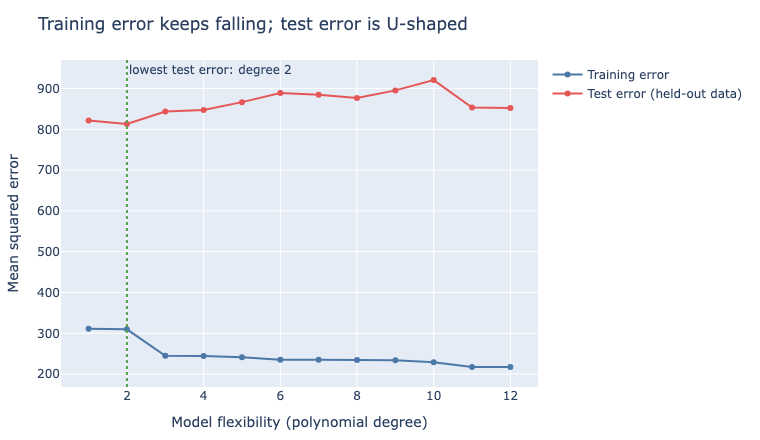

In [9]:
show(fig_train_vs_test_error())

## k-fold cross-validation

A single validation split produces the widest spread of estimated test error across repeats. 5-fold and 10-fold CV narrow that spread considerably, and LOOCV narrows it further still.

In [10]:
def fig_validation_strategy_variance() -> go.Figure:
    strategies = ["Single 50/50\nvalidation split", "5-fold CV", "10-fold CV", "Leave-one-out CV"]
    n_repeats = 60
    n = 40
    degree = 3
    results = {s: [] for s in strategies}

    for rep in range(n_repeats):
        x, y = make_dataset(n=n, seed=1000 + rep)

        # single validation split (a fresh random split each repeat)
        idx = RNG.permutation(n)
        half = n // 2
        tr_idx, va_idx = idx[:half], idx[half:]
        _, mse = fit_poly_train_test_error(x[tr_idx], y[tr_idx], x[va_idx], y[va_idx], degree)
        results["Single 50/50\nvalidation split"].append(mse)

        for k, label in [(5, "5-fold CV"), (10, "10-fold CV"), (n, "Leave-one-out CV")]:
            folds = np.array_split(RNG.permutation(n), k)
            fold_mses = []
            for fold in folds:
                mask = np.ones(n, dtype=bool)
                mask[fold] = False
                if mask.sum() < degree + 2 or len(fold) == 0:
                    continue
                _, mse = fit_poly_train_test_error(x[mask], y[mask], x[fold], y[fold], degree)
                fold_mses.append(mse)
            results[label].append(np.mean(fold_mses))

    fig = go.Figure()
    colors = ["#F58518", "#4C78A8", "#54A24B", "#B279A2"]
    for strat, color in zip(strategies, colors):
        fig.add_trace(go.Box(y=results[strat], name=strat, marker_color=color, boxmean=True))
    fig.update_layout(
        title="Estimated test error across 60 repeats, by validation strategy",
        yaxis_title="Estimated mean squared error",
        margin=dict(t=60, l=60, r=30, b=80),
    )
    return fig

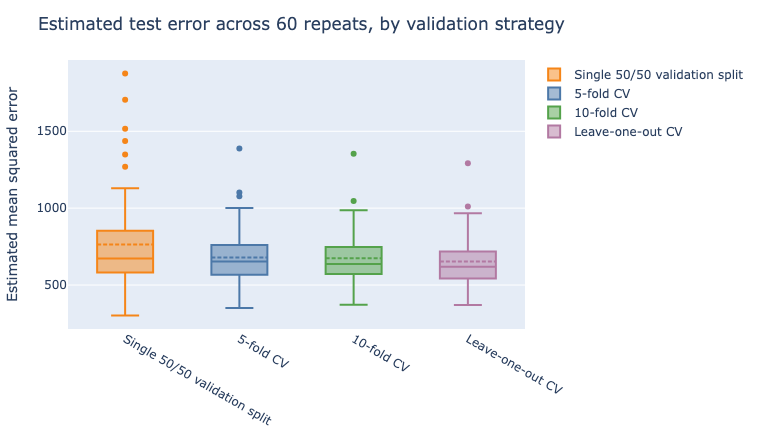

In [11]:
show(fig_validation_strategy_variance())

## Cross-validation for model selection: picking lambda

Cross-validated error traces a U-shape in lambda: the minimum marks the value cross-validation would select, and that minimum firms up, becoming less sensitive to the particular split, once k grows from 3 to 10.

In [12]:
def fig_lambda_selection() -> go.Figure:
    x, y = make_dataset(n=50, noise=30, seed=7)
    lambdas = np.logspace(-2, 3, 40)
    k_values = [3, 10]
    frames = []
    for k in k_values:
        folds = np.array_split(RNG.permutation(len(x)), k)
        cv_curve = []
        for lam in lambdas:
            fold_mses = []
            for fold in folds:
                mask = np.ones(len(x), dtype=bool)
                mask[fold] = False
                pred = ridge_fit_predict(x[mask], y[mask], x[fold], lam)
                fold_mses.append(np.mean((pred - y[fold]) ** 2))
            cv_curve.append(np.mean(fold_mses))
        best_lam = lambdas[int(np.argmin(cv_curve))]
        frames.append(
            go.Frame(
                name=f"k={k}",
                data=[go.Scatter(x=lambdas, y=cv_curve, mode="lines+markers",
                                  line=dict(color="#4C78A8"))],
                layout=go.Layout(
                    shapes=[dict(type="line", x0=best_lam, x1=best_lam, y0=0, y1=1,
                                 yref="paper", line=dict(color="#E45756", dash="dot"))],
                    annotations=[dict(x=np.log10(best_lam), y=1.05, yref="paper",
                                       xref="x", showarrow=False,
                                       text=f"CV-selected lambda = {best_lam:.2f}",
                                       font=dict(color="#E45756"))],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="k-fold CV error as regularization strength (lambda) changes",
        xaxis_title="lambda",
        xaxis_type="log",
        yaxis_title="Cross-validated mean squared error",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Number of folds: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=90, l=60, r=30, b=50),
    )
    return fig

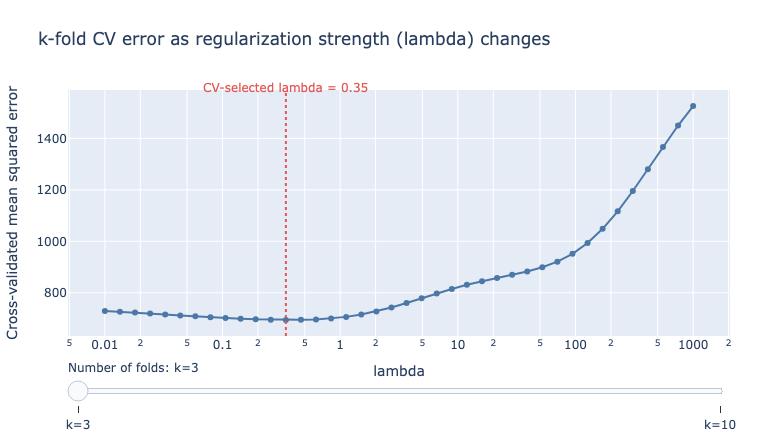

In [13]:
show(fig_lambda_selection())

## A Bayesian perspective

ELPD rises with model complexity while the model is still capturing the underlying structure, peaking around degree 2, then falls as added flexibility starts fitting noise, the mirror image of the test-error curve in the first figure of this chapter.

In [14]:
def fig_elpd_by_complexity() -> go.Figure:
    x_train, y_train = make_dataset(n=40, seed=1)
    x_test, y_test = make_dataset(n=300, seed=321)
    degrees = list(range(1, 11))
    elpd_approx = []
    for d in degrees:
        coeffs = np.polyfit(x_train, y_train, d)
        resid_train = y_train - np.polyval(coeffs, x_train)
        sigma = np.std(resid_train) + 1e-6
        pred_test = np.polyval(coeffs, x_test)
        # approximate held-out log predictive density under a Gaussian likelihood,
        # standing in for what PSIS-LOO estimates from posterior draws
        log_dens = stats.norm.logpdf(y_test, loc=pred_test, scale=sigma)
        elpd_approx.append(np.sum(log_dens) / len(x_test) * len(x_train))

    best_d = degrees[int(np.argmax(elpd_approx))]
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=degrees, y=elpd_approx, mode="lines+markers",
                              line=dict(color="#72B7B2")))
    fig.add_vline(x=best_d, line=dict(color="#E45756", dash="dot"),
                  annotation_text=f"highest ELPD: degree {best_d}")
    fig.update_layout(
        title="Expected log predictive density (ELPD) by model complexity",
        xaxis_title="Model flexibility (polynomial degree)",
        yaxis_title="Approximate ELPD (higher is better)",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

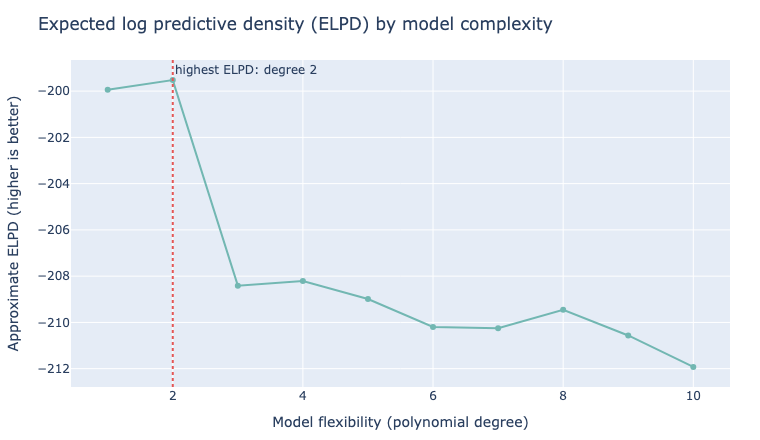

In [15]:
show(fig_elpd_by_complexity())